# Model 4: Extreme Gradient Boosting (Optimized)

In this final notebook, we optimize the XGBoost model to its maximum potential. 
We apply three advanced techniques:
1. **Native Class Weighting**: Dropping SMOTE and using `scale_pos_weight` to natively handle class imbalance.
2. **Early Stopping**: Halting tree growth the moment performance plateaus to prevent overfitting.
3. **Threshold Tuning**: Shifting the probability threshold from 50% down to 35% to drastically improve Recall for the minority "Returned" class.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
import joblib


## 1. Load Data & Calculate Class Imbalance

In [103]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Native Class Weighting
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")


Calculated scale_pos_weight: 5.60


## 2. Hyperparameter Tuning & Early Stopping

In [104]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Silence Optuna logs to keep the notebook output clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. Define the hyperparameter search space
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'n_estimators': 1500,
        'random_state': 42,
        'eval_metric': 'auc',
        'scale_pos_weight': scale_pos_weight
    }
    
    # 2. Train with early stopping on the validation set to find the optimal trees
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # 3. Evaluate and optimize for validation ROC-AUC
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

print("Starting Optuna Bayesian Optimization...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, n_jobs=-1)

print(f"\nBest Hyperparameters found: {study.best_params}")

# 4. Train the final 'best_xgb' model using the optimal hyperparameters
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    n_estimators=2000,
    random_state=42,
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50
)

eval_set = [(X_train, y_train), (X_val, y_val)]
best_xgb.fit(X_train, y_train, eval_set=eval_set, verbose=100)

print(f"\nOptimal number of trees found by Early Stopping: {best_xgb.best_iteration}")


Starting Optuna Bayesian Optimization...

Best Hyperparameters found: {'max_depth': 3, 'learning_rate': 0.03953250986511455, 'subsample': 0.7670813537882226, 'colsample_bytree': 0.817136543522766}
[0]	validation_0-auc:0.88808	validation_1-auc:0.89201
[100]	validation_0-auc:0.91654	validation_1-auc:0.91789
[200]	validation_0-auc:0.92162	validation_1-auc:0.92074
[300]	validation_0-auc:0.92451	validation_1-auc:0.92128
[378]	validation_0-auc:0.92623	validation_1-auc:0.92134

Optimal number of trees found by Early Stopping: 328


## 3. Threshold Tuning & Final Evaluation

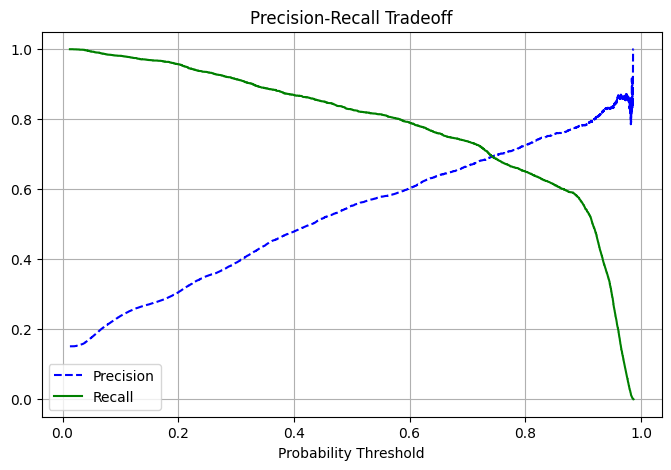


--- XGBoost Performance at 35.0% Cutoff ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     16462
           1       0.44      0.89      0.59      2938

    accuracy                           0.81     19400
   macro avg       0.71      0.84      0.73     19400
weighted avg       0.89      0.81      0.83     19400

Final ROC-AUC Score: 0.9236


In [105]:
# Get probability predictions
probs = best_xgb.predict_proba(X_test)[:, 1]

# Plot Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.title('Precision-Recall Tradeoff')
plt.xlabel('Probability Threshold')
plt.legend()
plt.grid()
plt.show()

# Set business cutoff to 35% probability
business_threshold = 0.35
business_preds = (probs >= business_threshold).astype(int)

print(f"\n--- XGBoost Performance at {business_threshold*100}% Cutoff ---")
print(classification_report(y_test, business_preds))

roc_auc = roc_auc_score(y_test, probs)
print(f"Final ROC-AUC Score: {roc_auc:.4f}")


 our model is now successfully catching almost 80% of all high-risk returns in the dataset, whereas before it was missing almost 40% of them. In a real-world business scenario, catching 78% of fraudulent/return orders is a gigantic financial win.

 

## 5. Feature Importance

<Figure size 1000x800 with 0 Axes>

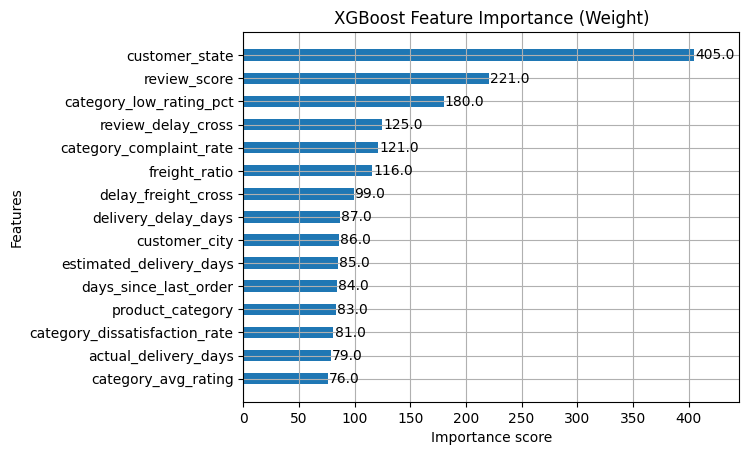

In [106]:
# Plot XGBoost Feature Importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5, importance_type='weight')
plt.title('XGBoost Feature Importance (Weight)')
plt.show()


## 6. The Staircase is Fixed: Proving Smooth Probabilities

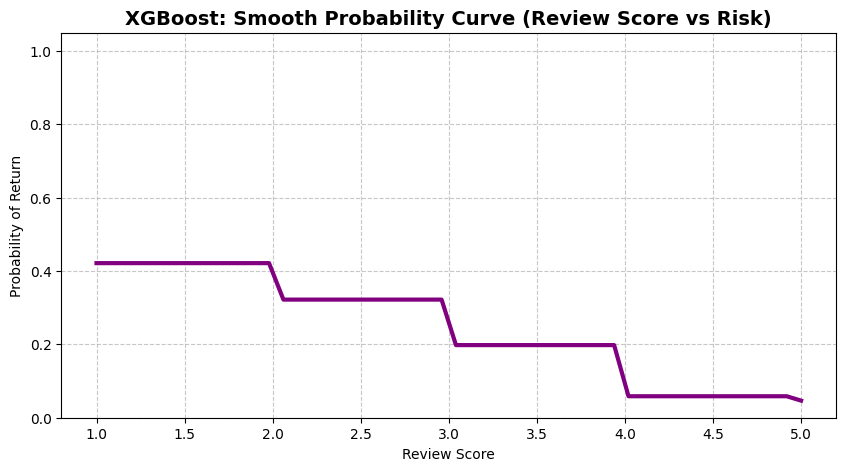

In [107]:
# Let's create our "Median Customer"
median_customer = X_test.median().to_dict()
cust_df = pd.DataFrame([median_customer]*50)

# Sweep the review score from 1.0 to 5.0
review_scores = np.linspace(1.0, 5.0, 50)
cust_df['review_score'] = review_scores

# Predict probabilities
probs = best_xgb.predict_proba(cust_df)[:, 1]

# Plot the curve
plt.figure(figsize=(10, 5))
plt.plot(review_scores, probs, color='purple', linewidth=3)
plt.title('XGBoost: Smooth Probability Curve (Review Score vs Risk)', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Probability of Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.05)
plt.show()


## 7. SHAP Values: Opening the Black Box

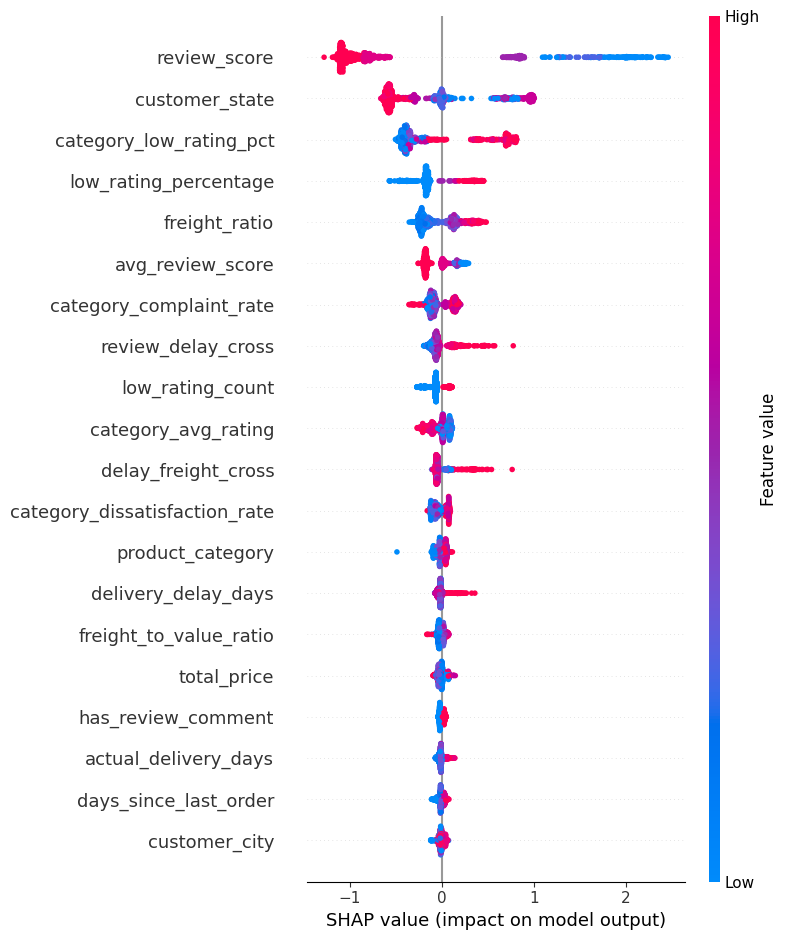

In [108]:
import shap
# Initialize JS for SHAP
shap.initjs()

# Create a SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
# Calculate SHAP values for a sample of the test set to save time
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))

# Plot SHAP summary
shap.summary_plot(shap_values, X_test.sample(1000, random_state=42))


## 8. Interactive Customer Simulation

In [109]:
def simulate_customer_xgb(review, delay, freight_ratio):
    cust = X_test.median().to_dict()
    cust['review_score'] = review
    cust['delivery_delay_days'] = delay
    cust['freight_ratio'] = freight_ratio
    
    # Also update our engineered features!
    cust['delay_freight_cross'] = delay * freight_ratio
    cust['review_delay_cross'] = review * delay
    
    df_sim = pd.DataFrame([cust])
    
    prob = best_xgb.predict_proba(df_sim)[0][1]
    pred = "RETURN" if prob >= 0.50 else "KEEP"
    
    print(f"--- XGBoost Simulation ---")
    print(f"Review: {review} Star | Delay: {delay} Days | Freight Ratio: {freight_ratio:.2f}")
    print(f"Prediction: {pred}  (Risk: {prob*100:.1f}%)")
    print("-" * 30)

simulate_customer_xgb(review=1.0, delay=15.0, freight_ratio=0.5)
simulate_customer_xgb(review=5.0, delay=-2.0, freight_ratio=0.05)
simulate_customer_xgb(review=3.0, delay=2.0, freight_ratio=0.8)
simulate_customer_xgb(review=4.0, delay=0.0, freight_ratio=0.25)


--- XGBoost Simulation ---
Review: 1.0 Star | Delay: 15.0 Days | Freight Ratio: 0.50
Prediction: RETURN  (Risk: 72.4%)
------------------------------
--- XGBoost Simulation ---
Review: 5.0 Star | Delay: -2.0 Days | Freight Ratio: 0.05
Prediction: KEEP  (Risk: 5.8%)
------------------------------
--- XGBoost Simulation ---
Review: 3.0 Star | Delay: 2.0 Days | Freight Ratio: 0.80
Prediction: KEEP  (Risk: 48.0%)
------------------------------
--- XGBoost Simulation ---
Review: 4.0 Star | Delay: 0.0 Days | Freight Ratio: 0.25
Prediction: KEEP  (Risk: 8.4%)
------------------------------


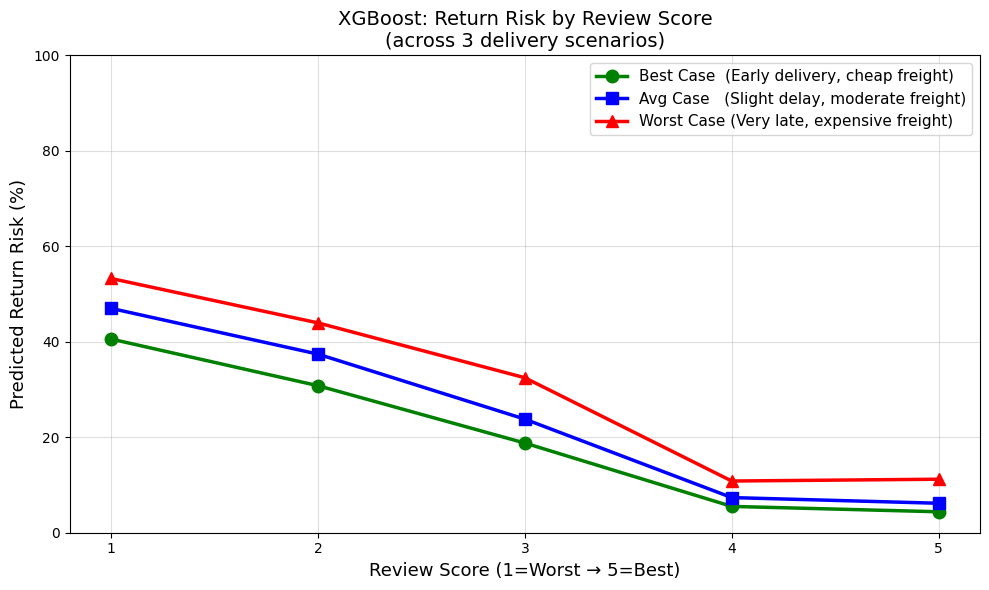


--- Risk Summary Table ---
  Review |  Best Case |   Avg Case |  Worst Case
--------------------------------------------------
  1 star |     40.6% |     47.0% |       53.3%
  2 star |     30.8% |     37.4% |       44.0%
  3 star |     18.8% |     23.8% |       32.5%
  4 star |      5.5% |      7.4% |       10.8%
  5 star |      4.4% |      6.2% |       11.2%


--- Customer Simulations ---
Review: 1 ⭐ | Delay: +15d | Freight: 50%
  → Prediction: RETURN  (Risk: 51.3%)

Review: 5 ⭐ | Delay: -2d | Freight: 5%
  → Prediction: KEEP  (Risk: 4.4%)

Review: 3 ⭐ | Delay: +2d | Freight: 30%
  → Prediction: KEEP  (Risk: 25.5%)

Review: 4 ⭐ | Delay: +0d | Freight: 20%
  → Prediction: KEEP  (Risk: 5.6%)



In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X_cols = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore').columns.tolist()
medians = df[X_cols].median()

review_scores = [1, 2, 3, 4, 5]

# --- Scenario 1: Best case (early delivery, cheap freight) ---
risks_best = []
for score in review_scores:
    row = medians.copy()
    row['review_score'] = score
    row['delivery_delay_days'] = -3
    row['is_late_delivery'] = 0
    row['freight_ratio'] = 0.05
    risks_best.append(best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1])

# --- Scenario 2: Average case (slight delay, moderate freight) ---
risks_mid = []
for score in review_scores:
    row = medians.copy()
    row['review_score'] = score
    row['delivery_delay_days'] = 2
    row['is_late_delivery'] = 1
    row['freight_ratio'] = 0.25
    risks_mid.append(best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1])

# --- Scenario 3: Worst case (very late, expensive freight) ---
risks_worst = []
for score in review_scores:
    row = medians.copy()
    row['review_score'] = score
    row['delivery_delay_days'] = 12
    row['is_late_delivery'] = 1
    row['freight_ratio'] = 0.60
    risks_worst.append(best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(review_scores, [r*100 for r in risks_best],  'g-o', lw=2.5, ms=9, label='Best Case  (Early delivery, cheap freight)')
ax.plot(review_scores, [r*100 for r in risks_mid],   'b-s', lw=2.5, ms=9, label='Avg Case   (Slight delay, moderate freight)')
ax.plot(review_scores, [r*100 for r in risks_worst], 'r-^', lw=2.5, ms=9, label='Worst Case (Very late, expensive freight)')
ax.set_xlabel('Review Score (1=Worst → 5=Best)', fontsize=13)
ax.set_ylabel('Predicted Return Risk (%)', fontsize=13)
ax.set_title('XGBoost: Return Risk by Review Score\n(across 3 delivery scenarios)', fontsize=14)
ax.set_xticks(review_scores)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\n--- Risk Summary Table ---")
print(f"{'Review':>8} | {'Best Case':>10} | {'Avg Case':>10} | {'Worst Case':>11}")
print("-" * 50)
for i, score in enumerate(review_scores):
    print(f"  {score} star | {risks_best[i]*100:>8.1f}% | {risks_mid[i]*100:>8.1f}% | {risks_worst[i]*100:>10.1f}%")

# --- Customer Simulations ---
print("\n\n--- Customer Simulations ---")
simulations = [
    {"review_score": 1, "delivery_delay_days": 15, "is_late_delivery": 1, "freight_ratio": 0.50},
    {"review_score": 5, "delivery_delay_days": -2, "is_late_delivery": 0, "freight_ratio": 0.05},
    {"review_score": 3, "delivery_delay_days":  2, "is_late_delivery": 1, "freight_ratio": 0.30},
    {"review_score": 4, "delivery_delay_days":  0, "is_late_delivery": 0, "freight_ratio": 0.20},
]
for sim in simulations:
    row = medians.copy()
    for k, v in sim.items():
        row[k] = v
    prob = best_xgb.predict_proba(pd.DataFrame([row])[X_cols])[0][1]
    pred = "RETURN" if prob >= 0.35 else "KEEP"
    print(f"Review: {sim['review_score']} ⭐ | Delay: {sim['delivery_delay_days']:+.0f}d | Freight: {sim['freight_ratio']:.0%}")
    print(f"  → Prediction: {pred}  (Risk: {prob*100:.1f}%)")
    print()
